Extracting EDF parameters from Dataset/Signals/mesa-sleep-0002.edf...
Setting channel info structure...
Creating raw.info structure...


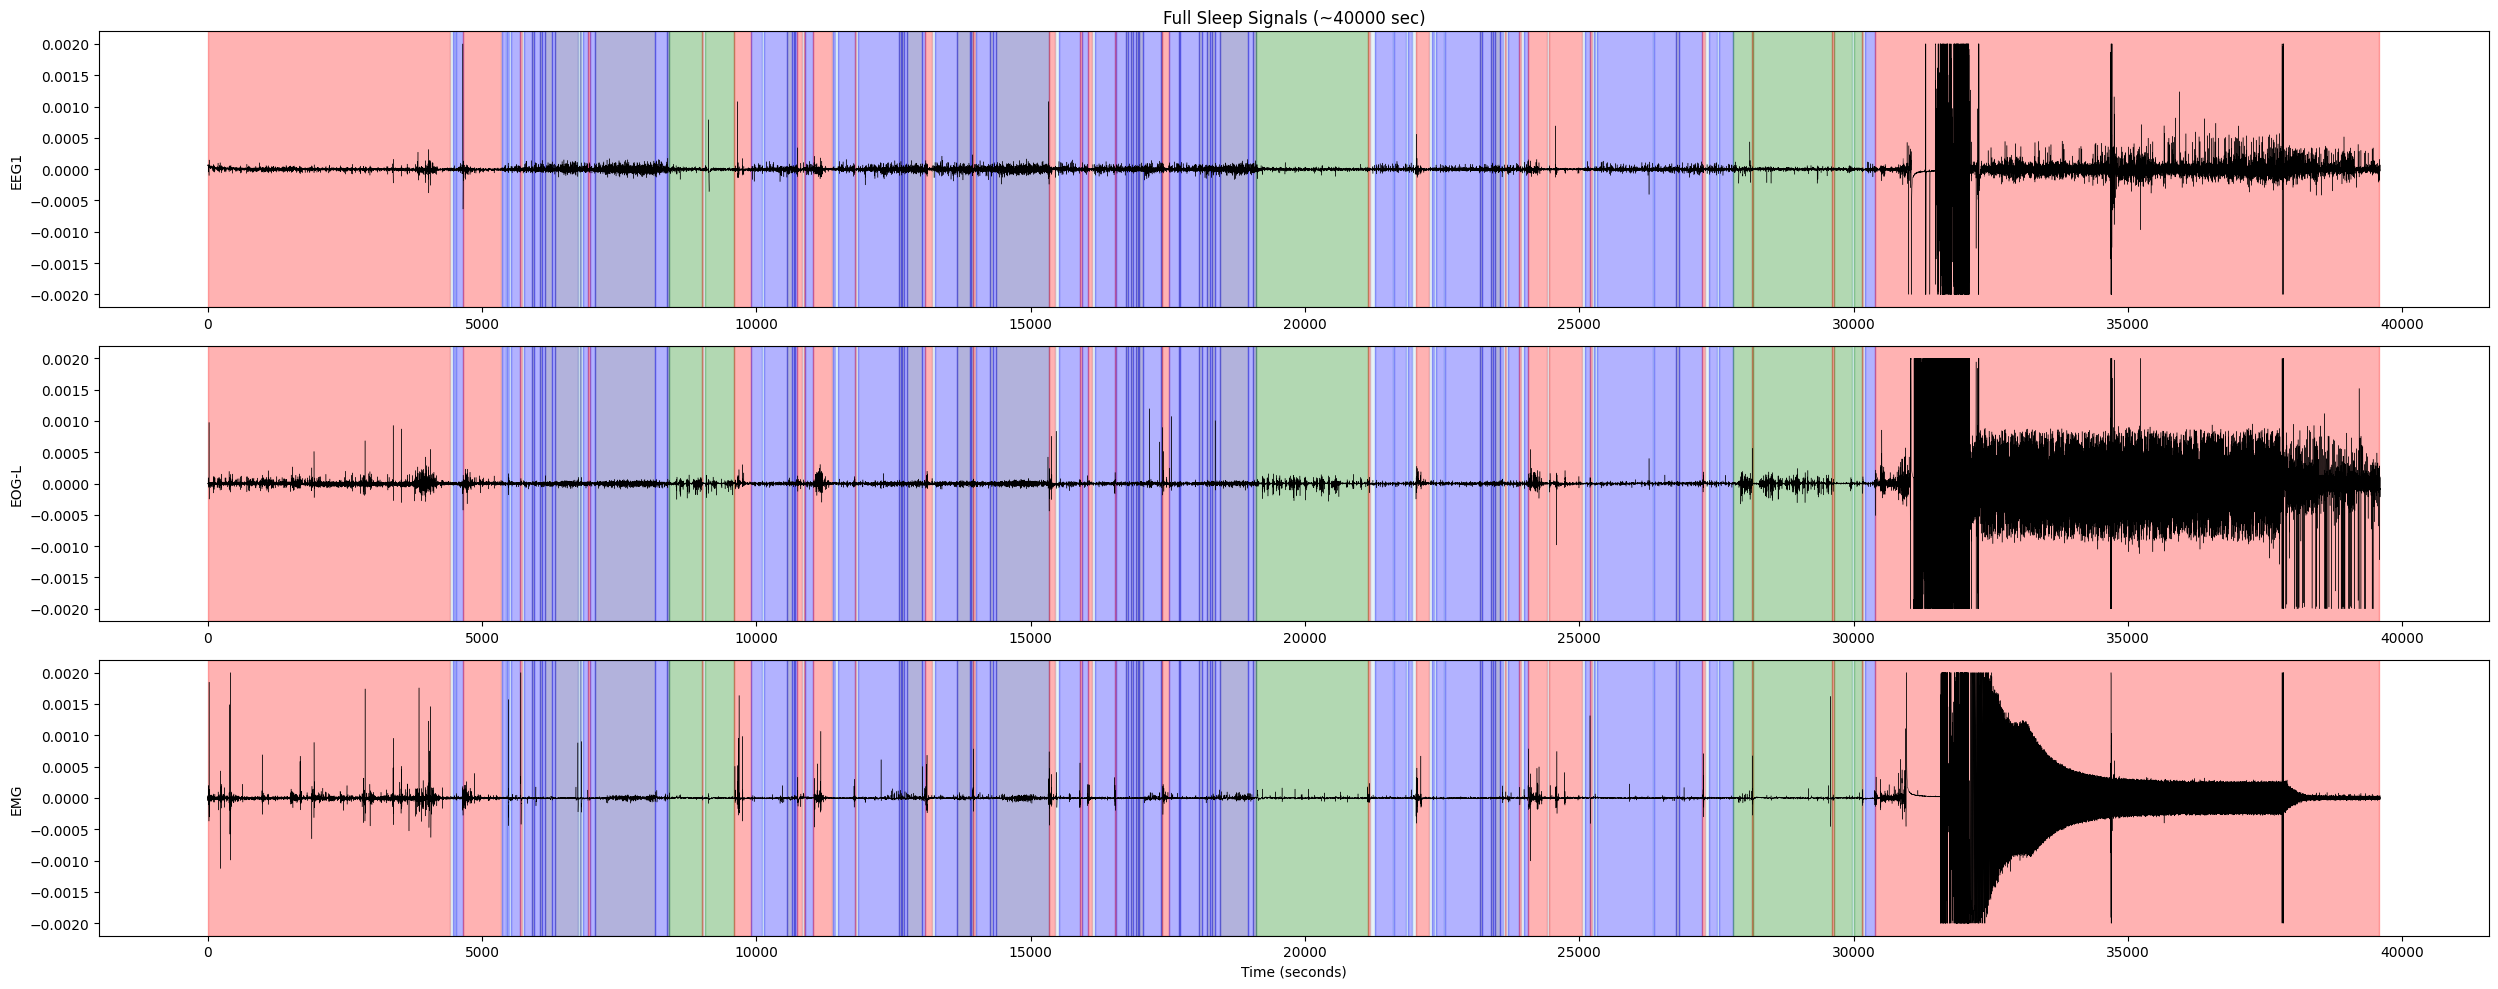

In [11]:
import mne
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0002-nsrr.xml"

channels_to_plot = ['EEG1', 'EOG-L', 'EMG']

# قراءة XML
tree = ET.parse(xml_file)
root = tree.getroot()

events = [e for e in root.findall(".//ScoredEvent")
          if e.find("EventType").text == "Stages|Stages"]

colors = {
    "Wake|0": "red",
    "Stage 1 sleep|1": "lightblue",
    "Stage 2 sleep|2": "blue",
    "Stage 3 sleep|3": "darkblue",
    "REM sleep|5": "green"
}

raw = mne.io.read_raw_edf(edf_file, preload=False)
sfreq = raw.info['sfreq']

plt.figure(figsize=(25, 10))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i + 1)

    data = raw.get_data(picks=ch)[0]
    times = np.arange(len(data)) / sfreq


    step = 200
    data = data[::step]
    times = times[::step]

    # رسم الإشارة
    ax.plot(times, data, color='black', linewidth=0.3)

    # رسم الـ stages
    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text
        color = colors.get(stage, "gray")

        ax.axvspan(start, start + duration, color=color, alpha=0.3)

    ax.set_ylabel(ch)

    if i == 0:
        ax.set_title("Full Sleep Signals (~40000 sec)")

    if i == len(channels_to_plot) - 1:
        ax.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

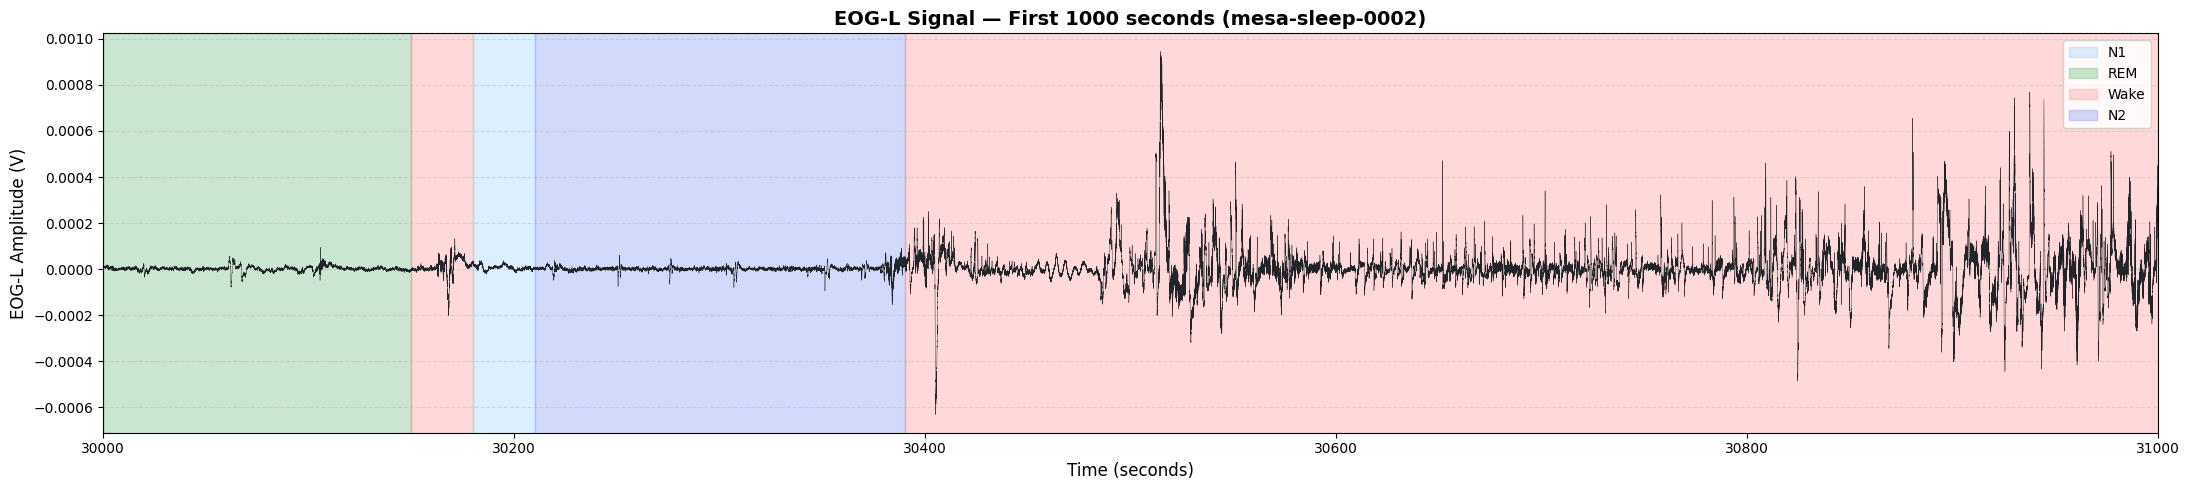

✅ Done! Saved as eog_signal_preview.png


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET


edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0002-nsrr.xml"

START_SEC = 30000   
DURATION_SEC = 1000 


tree = ET.parse(xml_file)
root = tree.getroot()
events = [e for e in root.findall(".//ScoredEvent")
          if e.find("EventType").text == "Stages|Stages"]

stage_colors = {
    "Wake|0":           ("#FF6B6B", "Wake"),
    "Stage 1 sleep|1":  ("#74C0FC", "N1"),
    "Stage 2 sleep|2":  ("#4C6EF5", "N2"),
    "Stage 3 sleep|3":  ("#1864AB", "N3"),
    "REM sleep|5":      ("#2F9E44", "REM"),
}


raw = mne.io.read_raw_edf(edf_file, preload=False, verbose=False)
sfreq = raw.info['sfreq']

start_sample = int(START_SEC * sfreq)
end_sample   = int((START_SEC + DURATION_SEC) * sfreq)

data = raw.get_data(picks='EOG-L')[0]
data = data[start_sample:end_sample]
times = np.arange(len(data)) / sfreq + START_SEC


fig, ax = plt.subplots(figsize=(22, 5))


ax.plot(times, data, color='#212529', linewidth=0.3, zorder=2)

legend_added = set()
for e in events:
    start = float(e.find("Start").text)
    dur   = float(e.find("Duration").text)
    stage = e.find("EventConcept").text

    if start + dur < START_SEC or start > START_SEC + DURATION_SEC:
        continue

    color, label = stage_colors.get(stage, ("#CCC", "Unknown"))
    show_label = label if label not in legend_added else ""
    if show_label:
        legend_added.add(label)

    ax.axvspan(max(start, START_SEC), min(start + dur, START_SEC + DURATION_SEC),
               color=color, alpha=0.25, label=show_label, zorder=1)


ax.set_xlim(START_SEC, START_SEC + DURATION_SEC)
ax.set_xlabel("Time (seconds)", fontsize=12)
ax.set_ylabel("EOG-L Amplitude (V)", fontsize=12)
ax.set_title(f"EOG-L Signal — First {DURATION_SEC} seconds (mesa-sleep-0002)", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.85, fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("eog_signal_preview.png", dpi=150)
plt.show()
print("✅ Done! Saved as eog_signal_preview.png")

In [3]:
import os
import mne
import numpy as np
import xml.etree.ElementTree as ET


CHANNELS = ['EOG-L']          
TARGET_SFREQ = 100
EPOCH_SEC = 30
EPOCH_LENGTH = TARGET_SFREQ * EPOCH_SEC  

STAGE_MAPPING = {
    "Wake|0": 0,
    "Stage 1 sleep|1": 1,
    "Stage 2 sleep|2": 2,
    "Stage 3 sleep|3": 3,
    "REM sleep|5": 4
}

def process_single_record(edf_path, xml_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick(['EOG-L'])        
    raw.resample(TARGET_SFREQ, npad="auto", verbose=False)
    
    data = raw.get_data().T    

    tree = ET.parse(xml_path)
    root = tree.getroot()
    events = [e for e in root.findall(".//ScoredEvent") 
              if e.find("EventType").text == "Stages|Stages"]

    num_epochs = int(data.shape[0] / EPOCH_LENGTH)
    labels = np.full(num_epochs, -1)

    for e in events:
        start_time = float(e.find("Start").text)
        duration   = float(e.find("Duration").text)
        stage_str  = e.find("EventConcept").text

        if stage_str in STAGE_MAPPING:
            start_epoch      = int(start_time / EPOCH_SEC)
            num_stage_epochs = int(duration / EPOCH_SEC)
            for i in range(start_epoch, min(start_epoch + num_stage_epochs, num_epochs)):
                labels[i] = STAGE_MAPPING[stage_str]

    data = data[:num_epochs * EPOCH_LENGTH]
 
    X = data.reshape(num_epochs, EPOCH_LENGTH, 1)
    y = labels

    valid = (y != -1)
    return X[valid], y[valid]


splits = ["train", "val", "test"]

for split in splits:
    print(f"\nProcessing {split.upper()}...")
    signals_dir     = f"Dataset/{split}/Signals"
    annotations_dir = f"Dataset/{split}/Annotations"
    save_dir        = f"Dataset/Processed_EOG-L/{split}"
    os.makedirs(save_dir, exist_ok=True)

    files = [f.replace(".edf","") for f in os.listdir(signals_dir) if f.endswith(".edf")]
    X_all, y_all = [], []

    for f in files:
        edf_path = os.path.join(signals_dir, f + ".edf")
        xml_path = os.path.join(annotations_dir, f + "-nsrr.xml")
        try:
            X_s, y_s = process_single_record(edf_path, xml_path)
            X_all.append(X_s)
            y_all.append(y_s)
            print(f"   {f} | X={X_s.shape}, y={y_s.shape}")
        except Exception as ex:
            print(f"   {f}: {ex}")

    if X_all:
        X_split = np.vstack(X_all)
        y_split = np.concatenate(y_all)
        save_path = os.path.join(save_dir, f"{split}_data.npz")
        np.savez_compressed(save_path, X=X_split, y=y_split)
        print(f" Saved → {save_path} | Shape: X={X_split.shape}")


🚀 Processing TRAIN...
  ❌ mesa-sleep-0002: std::bad_alloc
  ✅ mesa-sleep-0006 | X=(1079, 3000, 1), y=(1079,)
  ✅ mesa-sleep-0012 | X=(1427, 3000, 1), y=(1427,)
🎉 Saved → Dataset/Processed_EOG-L/train\train_data.npz | Shape: X=(2506, 3000, 1)

🚀 Processing VAL...
  ✅ mesa-sleep-0001 | X=(1439, 3000, 1), y=(1439,)
🎉 Saved → Dataset/Processed_EOG-L/val\val_data.npz | Shape: X=(1439, 3000, 1)

🚀 Processing TEST...
  ✅ mesa-sleep-0010 | X=(1199, 3000, 1), y=(1199,)
🎉 Saved → Dataset/Processed_EOG-L/test\test_data.npz | Shape: X=(1199, 3000, 1)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
train_data = np.load("Dataset/Processed_EOG/train/train_data.npz")
val_data   = np.load("Dataset/Processed_EOG/val/val_data.npz")
test_data  = np.load("Dataset/Processed_EOG/test/test_data.npz")

X_train, y_train = train_data['X'], train_data['y']
X_val,   y_val   = val_data['X'],   val_data['y']
X_test,  y_test  = test_data['X'],  test_data['y']

print(f"Train shape: {X_train.shape}")  # (N, 3000, 1)
weights = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))



Train shape: (3825, 3000, 1)
